线性串联节点
****

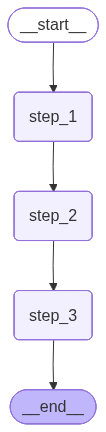

In [9]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph

class State(TypedDict):
    key: str
    value: str

def step_1(state:State):
    return {"key":"我是键"}

def step_2(state:State):
    return {"value":"我是值"}

def step_3(state:State):
    oldValue = state["value"]
    return {"value":f"我是旧值：{oldValue},我是新值X"} 

graph_builder = StateGraph(State)
graph_builder.add_node(step_1)
graph_builder.add_node(step_2)
graph_builder.add_node(step_3)

graph_builder.add_edge(START,"step_1")
graph_builder.add_edge("step_1","step_2")
graph_builder.add_edge("step_2","step_3")
graph_builder.add_edge("step_3",END)

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
graph.invoke({"key":"1"})

{'key': '我是键', 'value': '我是旧值：我是值,我是新值X'}

分支、分叉控制
****

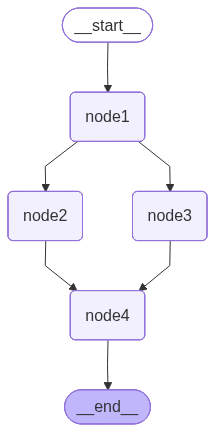

In [17]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Annotated允许为类提供额外的元数据，而不影响类型检查器对类型本身的理解
class State(TypedDict):
    arg: Annotated[list,operator.add]

def node1(state:State):
    print(f"添加node1到{state["arg"]}")
    return {"arg":["node1"]}

def node2(state:State):
    print(f"添加node2到{state["arg"]}")
    return {"arg":["node2"]}

def node3(state:State):
    print(f"添加node3到{state["arg"]}")
    return {"arg":["node3"]}

def node4(state:State):
    print(f"添加node4到{state["arg"]}")
    return {"arg":["node4"]}

builder = StateGraph(State)
builder.add_node(node1)
builder.add_node(node2)
builder.add_node(node3)
builder.add_node(node4)

builder.add_edge(START, "node1")
builder.add_edge("node1", "node2")
builder.add_edge("node1", "node3")
builder.add_edge("node2", "node4")
builder.add_edge("node3", "node4")
builder.add_edge("node4", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
graph.invoke({"arg":[]})

添加node1到[]
添加node2到['node1']
添加node3到['node1']
添加node4到['node1', 'node2', 'node3']


{'arg': ['node1', 'node2', 'node3', 'node4']}

条件&循环
****

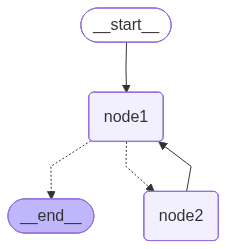

In [22]:
import operator
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Annotated允许为类提供额外的元数据，而不影响类型检查器对类型本身的理解
class State(TypedDict):
    arg: Annotated[list,operator.add]

def node1(state:State):
    print(f"添加node1到{state["arg"]}")
    return {"arg":["node1"]}

def node2(state:State):
    print(f"添加node2到{state["arg"]}")
    return {"arg":["node2"]}

def node3(state:State):
    print(f"添加node3到{state["arg"]}")
    return {"arg":["node3"]}

def node4(state:State):
    print(f"添加node4到{state["arg"]}")
    return {"arg":["node4"]}

builder = StateGraph(State)
builder.add_node(node1)
builder.add_node(node2)

def route(state: State) -> Literal["node2",END]:
    if len(state["arg"]) < 10:
        return "node2"
    else:
        return END

builder.add_edge(START,"node1")
builder.add_conditional_edges("node1",route)
builder.add_edge("node2","node1")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
graph.invoke({"arg":[]})

添加node1到[]
添加node2到['node1']
添加node1到['node1', 'node2']
添加node2到['node1', 'node2', 'node1']
添加node1到['node1', 'node2', 'node1', 'node2']
添加node2到['node1', 'node2', 'node1', 'node2', 'node1']
添加node1到['node1', 'node2', 'node1', 'node2', 'node1', 'node2']
添加node2到['node1', 'node2', 'node1', 'node2', 'node1', 'node2', 'node1']
添加node1到['node1', 'node2', 'node1', 'node2', 'node1', 'node2', 'node1', 'node2']
添加node2到['node1', 'node2', 'node1', 'node2', 'node1', 'node2', 'node1', 'node2', 'node1']
添加node1到['node1', 'node2', 'node1', 'node2', 'node1', 'node2', 'node1', 'node2', 'node1', 'node2']


{'arg': ['node1',
  'node2',
  'node1',
  'node2',
  'node1',
  'node2',
  'node1',
  'node2',
  'node1',
  'node2',
  'node1']}

利用recursion_limit限制循环次数，抛出异常并执行
****

In [26]:
from langgraph.errors import GraphRecursionError

try:
    # 限制5次结束
    graph.invoke({"arg":[]},{"recursion_limit":5})
except GraphRecursionError:
    print("recursion_limit:END")

添加node1到[]
添加node2到['node1']
添加node1到['node1', 'node2']
添加node2到['node1', 'node2', 'node1']
添加node1到['node1', 'node2', 'node1', 'node2']
recursion_limit:END
